# Sector-Constrained TN Drop
Independent variant of Nulling_CDF.ipynb. One TN per BS rectangle and horizontal sector.
Each serving sector must exceed every other sector by the configured power margin.
Indoor/outdoor type is fixed per region per macro; infeasible drops fail explicitly.
See TN_SECTOR_DROP.md for placement and association.
See FDD_MULTIPATH_ANALYSIS.md for multipath processing, FDD interpretation, and saved outputs.


### Fixed DL array and UL frequency sweep

- DL frequency is `f_dl = 7e9` Hz. BS element spacing stays at `c / (2*f_dl)` meters.
- `ul_frequency_percentages = [-20, -10, -5, 0, 5, 10, 20]` means `f_ul = f_dl*(1+p/100)`.
  Every percentage shares the same DL channels, user positions and TN scheduling.
- `ul_to_dl_mode="angle"`: estimate anonymous peaks at UL, rebuild their steering
  vectors at DL, retain the estimated UL power weights, and evaluate nulling on
  the actual DL channel. This does not assume instantaneous FDD CSI reciprocity.
  `"raw"` instead reuses UL vectors as a cross-frequency mismatch control.
- Each CDF has `len(lambda_ranges_music_est) * len(ul_frequency_percentages)`
  estimated curves, plus one no-nulling baseline. Set `plot_oracle=True` to add
  one DL oracle curve per lambda (independent of UL frequency).
- Nonzero FDD cases require disjoint bandwidths; zero is a mathematical control.
  With 200 MHz on each band, ±2% at 7 GHz overlaps; reduce both bandwidths below
  140 MHz to use that offset as a disjoint-band case.
- Existing normalized sensing power/noise and element-pattern models are retained.
  `music_covariance_mode="analytic"` uses an ideal covariance, not finite snapshots;
  `music_num_snapshots` represents actual sampling only in `"sample"` mode.


### Coherent multipath and NLOS

Set `max_depth` in the parameter cell and rerun from that cell. This is Sionna's
maximum number of interactions along a path, not a requested path count.
`max_depth=0` preserves the direct-path baseline; a positive value automatically
uses the coherent-path estimator. There is no separate multipath switch. All valid path
coefficients remain in the real channels and add coherently at the carrier;
`collapse_cir_to_narrowband()` selects time 0 without summing time samples.
The helper also supports `time_index=None` and a single frequency offset with
`tau`, but this experiment evaluates a static narrowband channel (no OFDM sweep).

`ntn_los_mode="natural"` lets geometry create LOS/NLOS links. `"nlos_only"`
artificially suppresses NTN direct paths; TN service links retain natural LOS.
Spatial smoothing estimates coherent path directions with smaller subarrays,
then correlated covariance fitting estimates full-array path weights. Nulling
uses the original full DL array. `multipath_top_k` / `multipath_energy_fraction`
only select estimated directions per sector; all physical paths remain in INR.
When enabled, the oracle uses every true DL path direction and power. UL and DL
share propagation settings and physical array, but are traced at their own frequencies.

Exact ray angles/CIRs are saved for diagnostics only; they never enter blind
MUSIC. Counts are reported per BS-UE link. Angular path matching cannot resolve
inherent planar front/back or spatial-aliasing ambiguities. Narrowband coherent
multipath and finite-snapshot error are separate: use `music_covariance_mode="sample"`
for the latter. Diffuse scattering needs nonzero scattering in the scene materials.

### Run outputs

20 Monte Carlo macros by default. Each experiment-cell execution creates a fresh
`result/YYYYMMDD_HHMMSS_microseconds/` with configuration, source snapshots, logs,
channel/path diagnostics, raw metrics, summary CSV, and PNG/PDF CDFs. Colors encode
lambda; a separate line-style legend encodes UL percentage and frequency.


In [1]:
import importlib
from pathlib import Path
from datetime import datetime
import json

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import chi2
from sionna.rt import load_scene
 
import SceneConfigSionnaSectorDrop as SceneConfigSionna
import multipath_support as mps
importlib.reload(mps)
import ntn_music_detection as nmd

importlib.reload(SceneConfigSionna)
importlib.reload(nmd)

import nulling_cdf_utils as ncu
importlib.reload(ncu)

from SceneConfigSionnaSectorDrop import SceneConfigSionna

# Public CIR helper (also re-exported by nmd); the experiment calls it internally.
from multipath_support import collapse_cir_to_narrowband

import sector_drop_reporting as reporting
importlib.reload(reporting)


<module 'sector_drop_reporting' from '/home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/sector_drop_reporting.py'>

In [2]:
# scene = load_scene("/workspace/shizhen/NTN-Nulling/Denver_Scene/Boulder/Boulder.xml")
# scene = load_scene("/workspace/shizhen/NTN-NULLING-NONCOH/blender_scene_big/10km_times_10km/10km_times_10km.xml")
scene = load_scene("Denver_scene/10kmwithfigure/10km.xml")

SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)


x range: [-5052.669, 5027.331]
y range: [-5046.508, 5043.492]


In [3]:
# Geometry and deployment
ntn_rx =20
tn_rx = 12
bs_row = 2
bs_col = 2
nbs = bs_row * bs_col
nsect = 3

# One UE per BS rectangle and horizontal sector (12 UEs total).
# Type is sampled once per region and preserved through all channel retries.
# Outdoor: ground + 1.8 m. Indoor: roof - 1.5 m.
# Mixed indoor/outdoor deployment uses the multipath settings below.
tn_outdoor_probability = 0.5
tn_association_margin_db = 3.0  # 10*log10(serving power / strongest of other 11).
tn_max_attempts = 256  # Maximum distinct grid candidates per region.
tn_candidates_per_batch = 16

# Satellite sampling configuration for Monte Carlo
satellite_resample_per_macro = True
satellite_azimuth_range_deg = (0.0, 360.0)
satellite_elevation_range_deg = (25, 90.0)
azimuth = float(satellite_azimuth_range_deg[0])
elevation = float(satellite_elevation_range_deg[0])

# Carrier and array configuration
f_dl = 7e9
fc = f_dl  # Existing path API: always trace the reference scene at DL.
ul_frequency_percentages = [-20.0, -10.0, -5.0, 0.0, 5.0, 10.0, 20.0]
ul_to_dl_mode = "angle"  # "angle": UL angles -> DL steering; "raw": reuse UL vectors.
plot_oracle = False  # Add frequency-independent true-DL reference curves if desired.
plot_snr = False
ul_frequency_percentages = ncu.validate_ul_frequency_percentages(ul_frequency_percentages)
ul_frequencies_hz = f_dl * (1 + np.asarray(ul_frequency_percentages) / 100)
bs_element_spacing_m = 299792458.0 / (2 * f_dl)
tx_antenna_rows = 8
tx_antenna_cols = 8
tn_rx_antenna_rows = 1
tn_rx_antenna_cols = 1
tx_antennas = tx_antenna_rows * tx_antenna_cols

# Sionna maximum number of interactions along a path (not the number of paths).
# 0: direct paths only; 1: up to one interaction; 2: up to two interactions, etc.
# Positive depths automatically use the existing coherent-path MUSIC pipeline.
max_depth = 3
max_depth = mps.validate_max_depth(max_depth)
ntn_los_mode = "natural"  # "natural": geometry determines LOS/NLOS; "nlos_only": remove NTN direct paths.
multipath_specular_reflection = True
multipath_refraction = True
multipath_diffuse_reflection = False  # Requires suitable nonzero material scattering coefficients.
multipath_diffraction = False
multipath_samples_per_src = 100_000
multipath_max_num_paths_per_src = 100_000
multipath_solver_seed = 42

# Estimation uses overlapping subarrays; DL transmission still uses the full 8x8 array.
music_spatial_smoothing = True  # False: unsmoothed MUSIC comparison, still using coherent data.
music_smoothing_rows = 6
music_smoothing_cols = 6
music_forward_backward = True
multipath_top_k = None  # Max estimated directions PER BS SECTOR; None keeps all accepted peaks.
multipath_energy_fraction = 1.0  # e.g. 0.95 keeps >=95% estimated path power, subject to top_k.
# These selection controls NEVER delete paths from the real UL/DL channels.

# TX sector orientation
tx_sector_yaw_offset_deg = 0.0
tx_head_down_deg = 6.0
tx_sector_roll_deg = 0.0

tx_sector_yaw_offset_rad = np.deg2rad(tx_sector_yaw_offset_deg)
# Sionna uses positive pitch to tilt the local +x boresight downward.
tx_sector_pitch_rad = np.deg2rad(tx_head_down_deg)
tx_sector_roll_rad = np.deg2rad(tx_sector_roll_deg)

# Monte Carlo setting
num_macro_sims = 20
show_progress = True
plot_layout_on_first_sim = False

# Noise, thresholds, and Blind MDL-MUSIC Detection setup
EkT = -174
B = 200e6  # DL evaluation bandwidth.
B_ul = B  # UL sensing bandwidth (used in BS receiver noise).
enforce_disjoint_bands = True  # Zero offset is exempt: mathematical regression control.
if enforce_disjoint_bands:
    for percentage, frequency in zip(ul_frequency_percentages, ul_frequencies_hz):
        if percentage != 0 and abs(frequency - f_dl) <= (B + B_ul) / 2:
            raise ValueError(
                f"UL offset {percentage:+g}% has overlapping/touching bands. "
                "Reduce B/B_ul or use a larger absolute percentage. "
                "For a purely mathematical overlap study, disable enforce_disjoint_bands."
            )
Tx_power_dbm = 35
Tx_power = 10 ** ((Tx_power_dbm - 30) / 10)
Tx_power_handheld_dbm = 23
Tx_power_handheld = 10 ** ((Tx_power_handheld_dbm - 30) / 10)

NF = 7
NF_vsat = 3
NF_bs = 2
N0_dBm = EkT + 10 * np.log10(B) + NF
N0 = 10 ** ((N0_dBm - 30) / 10)
N0_vsat = 10 ** ((EkT + 10 * np.log10(B) + NF_vsat - 30) / 10)
N0_bs = 10 ** ((EkT + 10 * np.log10(B_ul) + NF_bs - 30) / 10)

preamble_time = 20e-6
N0_sigma = N0_vsat / Tx_power / preamble_time
N0_sigma_handheld = 10 ** ((EkT + NF_bs - 30) / 10) / Tx_power_handheld / preamble_time

# lambda_ranges = [1e10, 1e11, 1e12, 1e13]
# lambda_ranges = [1e1, 1e2, 1e3]
lambda_ranges = None
# lambda_ranges_music_est = [1e10*2, 1e10*5, 1e10*8]
lambda_ranges_music_est = [1e10, 1e11, 1e12]
lambda_ranges_music_real = lambda_ranges_music_est
max_detected_b_terms = "all"
snr_threshold = -6
inr_threshold = -6
h_ntn_th = np.sqrt(10 ** (inr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
h_tn_th = np.sqrt(10 ** (snr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
threshold_peft_db = 10 * np.log10(np.abs(h_tn_th) ** 2)
p_fa = 1 / B
pfa_threshold = chi2.ppf(1 - p_fa, 2 * tx_antennas) / 2
h_ntn_pfa_th = np.sqrt(pfa_threshold * N0_sigma)
h_tn_pfa_th = np.sqrt(pfa_threshold * N0_sigma_handheld)
threshold_ntn_pfa_db = 10 * np.log10(np.abs(h_ntn_pfa_th) ** 2)
threshold_tn_pfa_db = 10 * np.log10(np.abs(h_tn_pfa_th) ** 2)

sionna_phi_is_global = True
theta_display_mode = "elevation"

blind_mdl_music_detection_name = "Blind MUSIC Detection"

# Blind MUSIC Detection model:
#   R_xx ~= sum_k g_k u_k u_k^H + sigma^2 I
#   with anonymous peaks (u_k, g_k) and an automatically estimated K.
# Blind MUSIC Detection tuning notes:
# - music_threshold controls truth-assisted per-user evaluation, not blind peak acceptance.
# - peak_max_noise_projection controls blind candidate acceptance.
# - If music_num_sources is set to an integer, it overrides automatic K estimation.
# - source_estimation='rank' is appropriate for an analytic covariance.
# - source_estimation='mdl' is retained as a per-TX diagnostic.
# - source_estimation='energy' is usually more aggressive.
# - music_energy_ratio is only used when source_estimation='energy'.
# - A larger music_energy_ratio usually yields a larger estimated K and looser detection.
music_num_sources = None
music_threshold = 3
music_covariance_mode = "analytic"
music_num_snapshots = 800
music_noise_var = N0_bs / Tx_power  # Legacy normalized sensing SNR; use Tx_power_handheld for 23 dBm UL.
# music_noise_var = 0
music_rng_seed = 20260910
position_rng_seed = 20260908
satellite_rng_seed = 20260909
music_source_estimation = "rank"
# music_source_estimation = "mdl"
# music_source_estimation = "energy"
music_energy_ratio = 0.98
music_rank_relative_threshold = 1e-5
music_rank_noise_margin = 1e-3
blind_mdl_music_detection_name = nmd.blind_music_detection_name(music_source_estimation)
music_reduce_ntn_ant = "max"
music_user_powers = None
music_use_sector_orientation = True
music_sector_yaw_offset_rad = float(tx_sector_yaw_offset_rad)
music_sector_pitch_rad = float(tx_sector_pitch_rad)
music_sector_roll_rad = float(tx_sector_roll_rad)
music_rotation_order = "zyx"
music_std_channel_mode = "conj"
music_std_manifold_label = "yz:+1"
music_std_flatten_order = "F"
music_std_scan_mode = "complex"
music_std_phi_offset_deg = 0.0
music_std_phi_mirror_about_sector = False
music_std_horizontal_sign = -1
music_sector_forward_only = True
# Search support is distinct from the sector's service coverage.
# Previous 60-degree cone: np.cos(np.deg2rad(60.0))
music_sector_forward_cos_min = 0.0
music_peak_min_sep_phi_deg = 0.0
music_peak_min_sep_theta_deg = 0.0
music_peak_max_correlation = 0.98
music_peak_refine = True
music_peak_refine_half_width_deg = 1.0
music_peak_refine_maxiter = 40
music_peak_local_maxima = True
music_peak_max_noise_projection = 0.2
music_covariance_refine = (max_depth == 0)
# The multipath branch fits a full correlated Q after spatial smoothing;
# the old diagonal/noncoherent covariance refinement is only used when disabled.
music_covariance_refine_maxiter = 60
music_covariance_refine_max_direction_step = 0.1
if music_covariance_refine:
    blind_mdl_music_detection_name += " + covariance fit"
music_phi_grid_deg = np.arange(0.0, 360.0, 0.5)
music_theta_grid_deg = np.arange(0.0, 180.5, 0.5)

print(
    f"TX sector orientation: yaw_offset={tx_sector_yaw_offset_deg:.1f} deg, "
    f"head_down={tx_head_down_deg:.1f} deg, roll={tx_sector_roll_deg:.1f} deg"
)
print(
    "Satellite sampling: "
    f"per_macro={satellite_resample_per_macro}, "
    f"azimuth_range={satellite_azimuth_range_deg}, "
    f"elevation_range={satellite_elevation_range_deg}"
)
print(f"h_tn_th = {h_tn_th:.4e}")
print(f"h_ntn_th = {h_ntn_th:.4e}")
print(f"TN Pfa threshold = {threshold_tn_pfa_db:.2f} dB")
print(f"NTN Pfa threshold = {threshold_ntn_pfa_db:.2f} dB")
print(f"Beamforming threshold = {threshold_peft_db:.2f} dB")
print(f"Detected NTN pair limit per TX = {max_detected_b_terms}")
print(
    f"MUSIC K={music_source_estimation}, rank_rel={music_rank_relative_threshold:.0e}, "
    f"peak_corr={music_peak_max_correlation:.2f}, refine={music_peak_refine}"
)

print(f"DL={f_dl/1e9:g} GHz, fixed BS spacing={bs_element_spacing_m*1e3:.4f} mm")
for percentage, frequency in zip(ul_frequency_percentages, ul_frequencies_hz):
    print(f"UL {percentage:+g}%: {frequency/1e9:g} GHz; spacing/lambda_UL={0.5*frequency/f_dl:g}")
print(f"Estimated CDF curves: {len(lambda_ranges_music_est)} lambdas x "
      f"{len(ul_frequency_percentages)} offsets = "
      f"{len(lambda_ranges_music_est)*len(ul_frequency_percentages)}; transfer={ul_to_dl_mode}")

if max_depth > 0:
    print(f"Sionna max_depth={max_depth}, NTN LOS policy={ntn_los_mode}; "
          f"smoothing={music_spatial_smoothing} ({music_smoothing_rows}x{music_smoothing_cols}), "
          f"top_k={multipath_top_k}, energy_fraction={multipath_energy_fraction}")
else:
    print("Sionna max_depth=0: original direct-path propagation and MUSIC settings.")


TX sector orientation: yaw_offset=0.0 deg, head_down=6.0 deg, roll=0.0 deg
Satellite sampling: per_macro=True, azimuth_range=(0.0, 360.0), elevation_range=(25, 90.0)
h_tn_th = 2.5328e-06
h_ntn_th = 2.5328e-06
TN Pfa threshold = -127.19 dB
NTN Pfa threshold = -55.18 dB
Beamforming threshold = -111.93 dB
Detected NTN pair limit per TX = all
MUSIC K=rank, rank_rel=1e-05, peak_corr=0.98, refine=True
DL=7 GHz, fixed BS spacing=21.4137 mm
UL -20%: 5.6 GHz; spacing/lambda_UL=0.4
UL -10%: 6.3 GHz; spacing/lambda_UL=0.45
UL -5%: 6.65 GHz; spacing/lambda_UL=0.475
UL +0%: 7 GHz; spacing/lambda_UL=0.5
UL +5%: 7.35 GHz; spacing/lambda_UL=0.525
UL +10%: 7.7 GHz; spacing/lambda_UL=0.55
UL +20%: 8.4 GHz; spacing/lambda_UL=0.6
Estimated CDF curves: 3 lambdas x 7 offsets = 21; transfer=angle
Sionna max_depth=3, NTN LOS policy=natural; smoothing=True (6x6), top_k=None, energy_fraction=1.0


In [4]:
import importlib
import multipath_support as mps
importlib.reload(mps)
import ntn_music_detection as nmd
importlib.reload(nmd)
import nulling_cdf_utils as ncu
importlib.reload(ncu)

result_dir = reporting.create_run_directory()

compute_positions_kwargs_mc = dict(
    ntn_rx=ntn_rx,
    tn_rx=tn_rx,
    azimuth=azimuth,
    elevation=elevation,
    centerBS=False,
    bs_grid=(bs_row, bs_col),
    bs_boundary=2500,
    tn_outdoor_probability=tn_outdoor_probability,
    tn_association_margin_db=tn_association_margin_db,
    tn_min_channel_norm=h_tn_th,
    tn_max_attempts=tn_max_attempts,
    tn_candidates_per_batch=tn_candidates_per_batch,
    tn_sector_yaw_offset_rad=tx_sector_yaw_offset_rad,
    tn_drop_output_dir=str(result_dir / "tn_drop"),
    ntn_building_ratio=0.8,
    plot_grid=plot_layout_on_first_sim,
    plot_bs=plot_layout_on_first_sim,
    plot_tn=plot_layout_on_first_sim,
    plot_ntn=plot_layout_on_first_sim,
)

compute_paths_kwargs_mc = dict(
    nsect=nsect,
    fc=fc,
    tx_rows=tx_antenna_rows,
    tx_cols=tx_antenna_cols,
    tn_rx_rows=tn_rx_antenna_rows,
    tn_rx_cols=tn_rx_antenna_cols,
    max_depth=max_depth,
    ntn_los_mode=ntn_los_mode,
    propagation_options=(dict(
        specular_reflection=multipath_specular_reflection,
        refraction=multipath_refraction,
        diffuse_reflection=multipath_diffuse_reflection,
        diffraction=multipath_diffraction,
        samples_per_src=multipath_samples_per_src,
        max_num_paths_per_src=multipath_max_num_paths_per_src,
        seed=multipath_solver_seed,
    ) if max_depth > 0 else None),
    bandwidth=B,
    tx_power_dbm=Tx_power_dbm,
    sector_yaw_offset_rad=tx_sector_yaw_offset_rad,
    sector_pitch_rad=tx_sector_pitch_rad,
    sector_roll_rad=tx_sector_roll_rad,
)

music_kwargs_mc = dict(
    tx_rows=int(tx_antenna_rows),
    tx_cols=int(tx_antenna_cols),
    nsect=int(nsect),
    pair_keys=None,
    detect_num_sources=music_num_sources,
    detect_threshold=music_threshold,
    detect_user_powers=music_user_powers,
    detect_noise_var=music_noise_var,
    detect_covariance_mode=music_covariance_mode,
    detect_num_snapshots=music_num_snapshots,
    detect_rng_seed=music_rng_seed,
    detect_source_estimation=music_source_estimation,
    detect_energy_ratio=music_energy_ratio,
    detect_rank_relative_threshold=music_rank_relative_threshold,
    detect_rank_noise_margin=music_rank_noise_margin,
    detect_reduce_rx_ant=music_reduce_ntn_ant,
    channel_mode=music_std_channel_mode,
    manifold_label=music_std_manifold_label,
    flatten_order=music_std_flatten_order,
    scan_mode=music_std_scan_mode,
    phi_offset_deg=music_std_phi_offset_deg,
    phi_mirror_about_sector=music_std_phi_mirror_about_sector,
    steering_horizontal_sign=music_std_horizontal_sign,
    use_sector_orientation=music_use_sector_orientation,
    sector_yaw_offset_rad=music_sector_yaw_offset_rad,
    sector_pitch_rad=music_sector_pitch_rad,
    sector_roll_rad=music_sector_roll_rad,
    rotation_order=music_rotation_order,
    sector_forward_only=music_sector_forward_only,
    sector_forward_cos_min=music_sector_forward_cos_min,
    peak_min_sep_phi_deg=music_peak_min_sep_phi_deg,
    peak_min_sep_theta_deg=music_peak_min_sep_theta_deg,
    peak_max_correlation=music_peak_max_correlation,
    peak_refine=music_peak_refine,
    peak_refine_half_width_deg=music_peak_refine_half_width_deg,
    peak_refine_maxiter=music_peak_refine_maxiter,
    peak_local_maxima=music_peak_local_maxima,
    peak_max_noise_projection=music_peak_max_noise_projection,
    covariance_refine=music_covariance_refine,
    covariance_refine_maxiter=music_covariance_refine_maxiter,
    covariance_refine_max_direction_step=music_covariance_refine_max_direction_step,
    phi_grid_deg=music_phi_grid_deg,
    theta_grid_deg=music_theta_grid_deg,
)

multipath_music_kwargs_mc = dict(
    subarray_rows=music_smoothing_rows, subarray_cols=music_smoothing_cols,
    spatial_smoothing=music_spatial_smoothing, forward_backward=music_forward_backward,
    top_k=multipath_top_k, energy_fraction=multipath_energy_fraction,
)

run_config = dict(scene_variant="sector_drop_fdd", scene_path="Denver_scene/10kmwithfigure/10km.xml",
                  plot_snr=plot_snr, f_dl=f_dl,
                  max_depth=max_depth, multipath_music=multipath_music_kwargs_mc,
                  channel_time_index=0, channel_frequency_offset_hz=0,
                  channel_model="coherent narrowband at carrier",
                  ul_frequency_percentages=ul_frequency_percentages, ul_frequencies_hz=ul_frequencies_hz,
                  ul_to_dl_mode=ul_to_dl_mode, bs_element_spacing_m=bs_element_spacing_m,
                  B_ul=B_ul, enforce_disjoint_bands=enforce_disjoint_bands,
                  plot_oracle=plot_oracle, music=music_kwargs_mc, positions=compute_positions_kwargs_mc, paths=compute_paths_kwargs_mc,
                  position_seed=position_rng_seed, satellite_seed=satellite_rng_seed, num_macro_sims=num_macro_sims,
                  satellite_resample=satellite_resample_per_macro, satellite_azimuth_range=satellite_azimuth_range_deg,
                  satellite_elevation_range=satellite_elevation_range_deg, tx_power=Tx_power, snr_noise_power=N0,
                  inr_noise_power=N0_vsat, h_tn_th=h_tn_th, lambda_ranges_music_est=lambda_ranges_music_est,
                  lambda_ranges_music_real=lambda_ranges_music_real, max_detected_b_terms=max_detected_b_terms,
                  bs_height_ground=SceneConfig.BS_height_above_ground, bs_height_roof=SceneConfig.BS_height_above_roof)
reporting.save_run_metadata(result_dir, run_config)
with reporting.capture_run_log(result_dir):
    print(f"Run outputs: {result_dir}", flush=True)
    nulling_cdf_results = ncu.run_nulling_cdf_experiment(
        SceneConfig,
        multipath_music_kwargs=multipath_music_kwargs_mc,
        ul_frequency_percentages=ul_frequency_percentages,
        ul_to_dl_mode=ul_to_dl_mode,
        num_macro_sims=num_macro_sims,
        compute_positions_kwargs=compute_positions_kwargs_mc,
        compute_paths_kwargs=compute_paths_kwargs_mc,
        lambda_ranges=lambda_ranges,
        lambda_ranges_music_est=lambda_ranges_music_est,
        lambda_ranges_music_real=lambda_ranges_music_real,
        h_tn_th=h_tn_th,
        tx_antennas=tx_antennas,
        tx_power=Tx_power,
        snr_noise_power=N0,
        inr_noise_power=N0_vsat,
        music_kwargs=music_kwargs_mc,
        sionna_phi_is_global=sionna_phi_is_global,
        theta_display_mode=theta_display_mode,
        plot_first_sim_only=plot_layout_on_first_sim,
        show_progress=show_progress,
        resample_satellite_per_macro=satellite_resample_per_macro,
        satellite_azimuth_range_deg=satellite_azimuth_range_deg,
        satellite_elevation_range_deg=satellite_elevation_range_deg,
        satellite_rng_seed=satellite_rng_seed,
        position_rng_seed=position_rng_seed,
        channel_cache_dir=result_dir / "channels",
        max_detected_b_terms=max_detected_b_terms,
    )

    metrics_path = ncu.save_experiment_metrics(
        nulling_cdf_results,
        result_dir=result_dir,
        output_name="nulling_cdf_metrics.npz",
    )

    # Per-percentage results retain all original metrics/diagnostics.
    results_by_percentage = nulling_cdf_results["by_percentage"]
    for percentage, case in results_by_percentage.items():
        stats = case["macro_stats"]
        rounds = sum(row["min_count"] for row in stats)
        print(f"UL {percentage:+g}% ({case['ul_frequency_hz']/1e9:g} GHz): "
              f"{len(stats)} macros, {rounds} rounds, "
              f"raw INR/SINR samples={case['raw_inr_db'].size}/{case['raw_sinr_db'].size}")
        if max_depth > 0:
            for row in stats:
                path_stats = row["path_metrics_dl"]
                print(f"  DL macro {row['sim_idx']}: {path_stats['valid_paths']} paths, "
                      f"LOS/NLOS/no-path BS-UE links="
                      f"{path_stats['los_links']}/{path_stats['nlos_links']}/{path_stats['no_path_links']}; "
                      f"UL-estimated directions={path_stats['estimated_paths']}, "
                      f"DL angular power coverage={path_stats['matched_path_power_fraction']:.3f}")
        for lambda_ in case["lambda_ranges_music_est"]:
            print(f"  lambda={lambda_:g}: INR={case['est_inr_db'][lambda_].size}, "
                  f"SINR={case['est_sinr_db'][lambda_].size}")
    print(f"Estimated curves per CDF: {nulling_cdf_results['num_estimated_curves']}")
    print(f"Metrics saved to: {metrics_path}")

reporting.save_summary(result_dir, nulling_cdf_results)
reporting.update_status(result_dir, "metrics_saved")


Run outputs: result/20260916_000256_575894


[Sector TN drop] accepted=5/12 candidates=12 outdoor=4/12 margin_required=3 dB


[Sector TN drop] accepted=12/12 candidates=124 outdoor=4/12 margin_required=3 dB


[Spatially smoothed MUSIC + correlated power fit sim] sim=0 UL_offset=-20% sat_az_deg=359.65 sat_el_deg=55.22 steering=sionna_array_positions peak_sep=(0.0,0.0)deg peak_corr=0.980 refine=True Kavg[used/mdl/rank/gap]=4.58/0.75/4.58/2.17 det_ntn=17 interf_ntn=18 matched_pairs=38 manifold_rho=1.000000 u_pairs=52 tx_used=12 phi_mae_deg=0.667 elev_mae_deg=0.189 u_rho_mean=0.995359 u_err_mean=4.641030e-03 g_rel_err_mean=2.169710e+02 u_rho_pw=0.999038 coverage95=0.999 B_nrmse=1.253e+00 cov_refine=False fit=8.779e-03->8.779e-03


[Spatially smoothed MUSIC + correlated power fit sim] sim=0 UL_offset=-10% sat_az_deg=359.65 sat_el_deg=55.22 steering=sionna_array_positions peak_sep=(0.0,0.0)deg peak_corr=0.980 refine=True Kavg[used/mdl/rank/gap]=4.50/0.58/4.50/2.08 det_ntn=17 interf_ntn=18 matched_pairs=38 manifold_rho=1.000000 u_pairs=52 tx_used=12 phi_mae_deg=0.610 elev_mae_deg=0.218 u_rho_mean=0.996423 u_err_mean=3.577244e-03 g_rel_err_mean=1.695924e+02 u_rho_pw=0.999499 coverage95=0.927 B_nrmse=6.472e-01 cov_refine=False fit=9.074e-03->9.074e-03


...

[Spatially smoothed MUSIC + correlated power fit sim] sim=19 UL_offset=+0% sat_az_deg=74.41 sat_el_deg=39.27 steering=sionna_array_positions peak_sep=(0.0,0.0)deg peak_corr=0.980 refine=True Kavg[used/mdl/rank/gap]=4.67/0.92/4.67/2.17 det_ntn=12 interf_ntn=16 matched_pairs=29 manifold_rho=1.000000 u_pairs=55 tx_used=12 phi_mae_deg=0.589 elev_mae_deg=0.042 u_rho_mean=0.958191 u_err_mean=4.180890e-02 g_rel_err_mean=3.400571e+08 u_rho_pw=0.974700 coverage95=0.955 B_nrmse=1.901e+00 cov_refine=False fit=1.076e-01->1.076e-01


[Spatially smoothed MUSIC + correlated power fit sim] sim=19 UL_offset=+5% sat_az_deg=74.41 sat_el_deg=39.27 steering=sionna_array_positions peak_sep=(0.0,0.0)deg peak_corr=0.980 refine=True Kavg[used/mdl/rank/gap]=4.42/0.83/4.42/2.08 det_ntn=14 interf_ntn=16 matched_pairs=27 manifold_rho=1.000000 u_pairs=53 tx_used=12 phi_mae_deg=0.327 elev_mae_deg=0.041 u_rho_mean=0.976926 u_err_mean=2.307360e-02 g_rel_err_mean=8.615087e+06 u_rho_pw=0.998885 coverage95=0.958 B_nrmse=2.139e+00 cov_refine=False fit=8.963e-02->8.963e-02


[Spatially smoothed MUSIC + correlated power fit sim] sim=19 UL_offset=+10% sat_az_deg=74.41 sat_el_deg=39.27 steering=sionna_array_positions peak_sep=(0.0,0.0)deg peak_corr=0.980 refine=True Kavg[used/mdl/rank/gap]=4.42/0.83/4.42/2.08 det_ntn=15 interf_ntn=16 matched_pairs=28 manifold_rho=1.000000 u_pairs=52 tx_used=12 phi_mae_deg=0.291 elev_mae_deg=0.092 u_rho_mean=0.941884 u_err_mean=5.811587e-02 g_rel_err_mean=1.772124e+07 u_rho_pw=0.975996 coverage95=0.972 B_nrmse=6.976e+00 cov_refine=False fit=1.119e-02->1.119e-02


[Spatially smoothed MUSIC + correlated power fit sim] sim=19 UL_offset=+20% sat_az_deg=74.41 sat_el_deg=39.27 steering=sionna_array_positions peak_sep=(0.0,0.0)deg peak_corr=0.980 refine=True Kavg[used/mdl/rank/gap]=4.42/0.75/4.42/2.58 det_ntn=13 interf_ntn=16 matched_pairs=24 manifold_rho=1.000000 u_pairs=52 tx_used=12 phi_mae_deg=0.339 elev_mae_deg=0.166 u_rho_mean=0.923624 u_err_mean=7.637610e-02 g_rel_err_mean=5.995148e+07 u_rho_pw=0.975350 coverage95=0.942 B_nrmse=5.457e-01 cov_refine=False fit=2.307e-02->2.307e-02


UL -20% (5.6 GHz): 20 macros, 20 rounds, raw INR/SINR samples=360/240
  DL macro 0: 181 paths, LOS/NLOS/no-path BS-UE links=108/31/101; UL-estimated directions=52, DL angular power coverage=0.803
  DL macro 1: 189 paths, LOS/NLOS/no-path BS-UE links=93/34/113; UL-estimated directions=53, DL angular power coverage=0.920
  DL macro 2: 223 paths, LOS/NLOS/no-path BS-UE links=117/33/90; UL-estimated directions=63, DL angular power coverage=0.636
  DL macro 3: 215 paths, LOS/NLOS/no-path BS-UE links=102/40/98; UL-estimated directions=60, DL angular power coverage=0.558
  DL macro 4: 206 paths, LOS/NLOS/no-path BS-UE links=75/47/118; UL-estimated directions=54, DL angular power coverage=0.610
  DL macro 5: 191 paths, LOS/NLOS/no-path BS-UE links=96/48/96; UL-estimated directions=61, DL angular power coverage=0.990
  DL macro 6: 224 paths, LOS/NLOS/no-path BS-UE links=117/38/85; UL-estimated directions=58, DL angular power coverage=0.765
  DL macro 7: 171 paths, LOS/NLOS/no-path BS-UE links=1

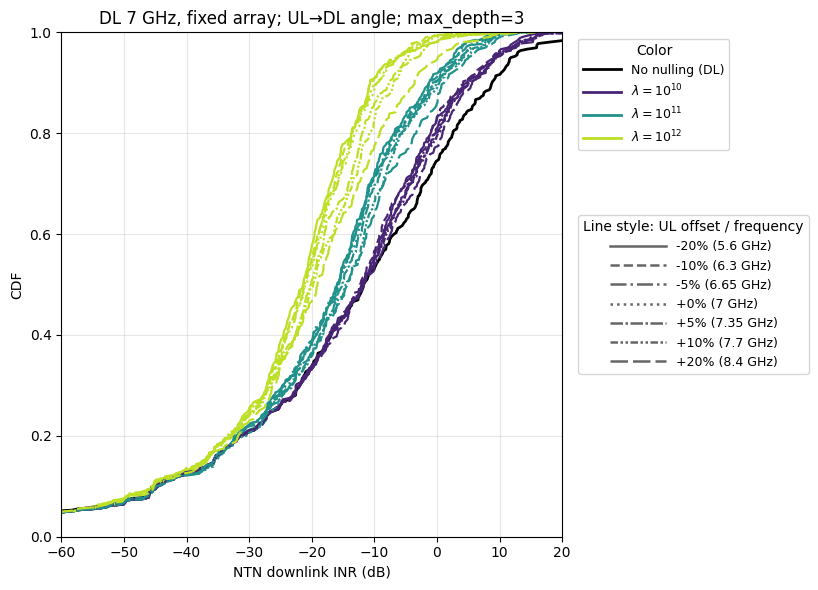

In [5]:
# Independent legend keys: lambda by color, UL percentage/frequency by line style.
# Oracle curves use the same DL truth in every case, so plot them only once.
def plot_frequency_sweep_cdf(metric, xlabel, xlim, filename):
    from matplotlib.lines import Line2D
    fig, ax = plt.subplots(figsize=(11, 6))
    first_case = next(iter(results_by_percentage.values()))
    estimated_lines = []
    def add_cdf(values, **style):
        values = np.sort(np.asarray(values, dtype=float).ravel())
        values = values[np.isfinite(values)]
        y = np.arange(1, len(values) + 1) / len(values) if len(values) else np.empty(0)
        return ax.plot(values, y, **style)[0]
    add_cdf(first_case[f"raw_{metric}_db"], color="black", linewidth=2,
            label="No nulling (DL)")
    lambdas = nulling_cdf_results["lambda_ranges_music_est"]
    colors = plt.get_cmap("viridis")(np.linspace(0.1, 0.9, max(len(lambdas), 1)))
    dash_styles = ["-", "--", "-.", ":", (0, (5, 1, 1, 1)),
                   (0, (3, 1, 1, 1, 1, 1)), (0, (7, 2))]
    for p_index, (percentage, case) in enumerate(results_by_percentage.items()):
        for l_index, lambda_ in enumerate(lambdas):
            line = add_cdf(
                case[f"est_{metric}_db"][float(lambda_)], color=colors[l_index],
                linestyle=dash_styles[p_index % len(dash_styles)], linewidth=1.6,
                label=f"λ={lambda_:g}, UL {percentage:+g}% ({case['ul_frequency_hz']/1e9:g} GHz)",
            )
            estimated_lines.append(line)
    if plot_oracle:
        for index, (lambda_, values) in enumerate(first_case[f"music_real_{metric}_db"].items()):
            add_cdf(values, color=colors[index % len(colors)], linestyle="-", marker="o", markersize=3,
                    markevery=max(1, len(values)//12), linewidth=1.2, alpha=0.65, label=f"DL {'path' if nulling_cdf_results.get('max_depth', 0) else 'channel'} oracle, λ={lambda_:g}")
    assert len(estimated_lines) == nulling_cdf_results["num_estimated_curves"]
    ax.set(xlabel=xlabel, ylabel="CDF", xlim=xlim, ylim=(0, 1),
           title=f"DL {nulling_cdf_results['dl_frequency_hz']/1e9:g} GHz, fixed array; "
                 f"UL→DL {nulling_cdf_results['ul_to_dl_mode']}; max_depth={nulling_cdf_results.get('max_depth', 0)}")
    ax.grid(True, alpha=0.3)
    def lambda_label(value):
        mantissa, exponent = f"{value:.6e}".split("e")
        coefficient = "" if float(mantissa) == 1 else f"{float(mantissa):g}\\times "
        return rf"$\lambda={coefficient}10^{{{int(exponent)}}}$"
    color_handles = [Line2D([], [], color="black", linewidth=2, label="No nulling (DL)")]
    color_handles += [Line2D([], [], color=colors[i], linewidth=2,
                            label=lambda_label(value)) for i, value in enumerate(lambdas)]
    color_legend = ax.legend(handles=color_handles, title="Color", fontsize=9,
                             loc="upper left", bbox_to_anchor=(1.02, 1), handlelength=3)
    ax.add_artist(color_legend)
    style_handles = [
        Line2D([], [], color="0.4", linestyle=dash_styles[i % len(dash_styles)], linewidth=1.8,
               label=f"{percentage:+g}% ({case['ul_frequency_hz']/1e9:g} GHz)")
        for i, (percentage, case) in enumerate(results_by_percentage.items())
    ]
    if plot_oracle:
        style_handles.append(Line2D([], [], color="0.4", marker="o", markersize=3,
                                    label="DL path oracle" if nulling_cdf_results.get("max_depth", 0)
                                    else "DL channel oracle"))
    ax.legend(handles=style_handles, title="Line style: UL offset / frequency", fontsize=9,
              loc="upper left", bbox_to_anchor=(1.02, 0.65), handlelength=4.5)
    fig.tight_layout(rect=(0, 0, 0.76, 1))
    import json
    style_map = dict(
        lambda_colors=[dict(lambda_value=float(value), rgba=colors[i].tolist())
                       for i, value in enumerate(lambdas)],
        ul_styles=[dict(percentage=float(p), frequency_hz=float(case["ul_frequency_hz"]),
                        linestyle=dash_styles[i % len(dash_styles)])
                   for i, (p, case) in enumerate(results_by_percentage.items())],
        no_nulling=dict(color="black", linestyle="-"), oracle_marker="o" if plot_oracle else None,
    )
    (result_dir / "cdf_style_map.json").write_text(json.dumps(style_map, indent=2))
    for extension in ("png", "pdf"):
        fig.savefig(result_dir / f"{filename}.{extension}", dpi=200, bbox_inches="tight")
    plt.show()
    return fig, ax

inr_fig, inr_ax = plot_frequency_sweep_cdf(
    "inr", "NTN downlink INR (dB)", (-60, 20), "nulling_inr_cdf",
)


In [6]:
# Optional TN SNR CDF, using the same lambda x percentage combinations.
if plot_snr:
    snr_fig, snr_ax = plot_frequency_sweep_cdf(
        "snr", "TN downlink SNR (dB)", (-10, 40), "nulling_tn_snr_cdf",
    )


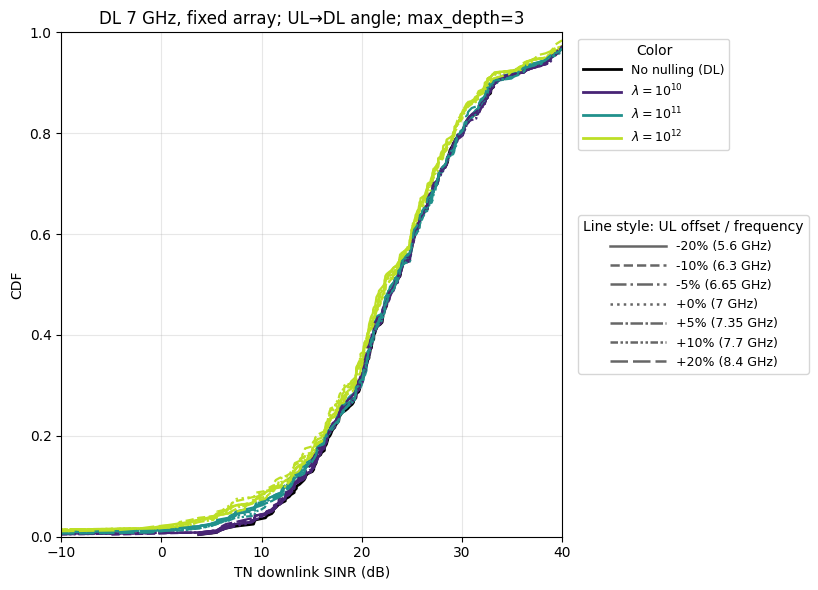

Completed run: /home/shizhen/my_project/NTN-NULLING-NONCOH-transaction/result/20260916_000256_575894


In [7]:
sinr_fig, sinr_ax = plot_frequency_sweep_cdf(
    "sinr", "TN downlink SINR (dB)", (-10, 40), "nulling_tn_sinr_cdf",
)

reporting.finish_run(result_dir)
print(f"Completed run: {result_dir.resolve()}")
